In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd

In [3]:
dataset_path = '/Users/macos/AIO/module 3 /w1/Thứ 8/Description/opsd_germany_daily.csv'
data = pd.read_csv(dataset_path)

In [7]:
data 

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.18400,NaN,NaN,NaN
2006-01-02,1380.52100,NaN,NaN,NaN
2006-01-03,1442.53300,NaN,NaN,NaN
2006-01-04,1457.21700,NaN,NaN,NaN
2006-01-05,1477.13100,NaN,NaN,NaN
...,...,...,...,...
2017-12-27,1263.94091,394.507,16.530,411.037
2017-12-28,1299.86398,506.424,14.162,520.586
2017-12-29,1295.08753,584.277,29.854,614.131


### time based indexing 

In [ ]:
data = data.set_index('Date')

In [10]:
data 

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.18400,NaN,NaN,NaN
2006-01-02,1380.52100,NaN,NaN,NaN
2006-01-03,1442.53300,NaN,NaN,NaN
2006-01-04,1457.21700,NaN,NaN,NaN
2006-01-05,1477.13100,NaN,NaN,NaN
...,...,...,...,...
2017-12-27,1263.94091,394.507,16.530,411.037
2017-12-28,1299.86398,506.424,14.162,520.586
2017-12-29,1295.08753,584.277,29.854,614.131


In [12]:
data.loc['2015':'2016']

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2015-01-01,1111.336,325.128,17.079,342.207
2015-01-02,1300.884,603.558,7.758,611.316
2015-01-03,1265.271,462.953,7.236,470.189
2015-01-04,1198.854,385.024,19.984,405.008
2015-01-05,1449.861,216.543,26.524,243.067
...,...,...,...,...
2015-12-27,1068.214,440.394,38.625,479.019
2015-12-28,1219.075,206.191,41.696,247.887
2015-12-29,1233.660,305.635,32.625,338.260


In [13]:
pd.to_datetime(data.index)

DatetimeIndex(['2006-01-01', '2006-01-02', '2006-01-03', '2006-01-04',
               '2006-01-05', '2006-01-06', '2006-01-07', '2006-01-08',
               '2006-01-09', '2006-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[ns]', name='Date', length=4383, freq=None)

### visualization 

<Axes: xlabel='Date'>

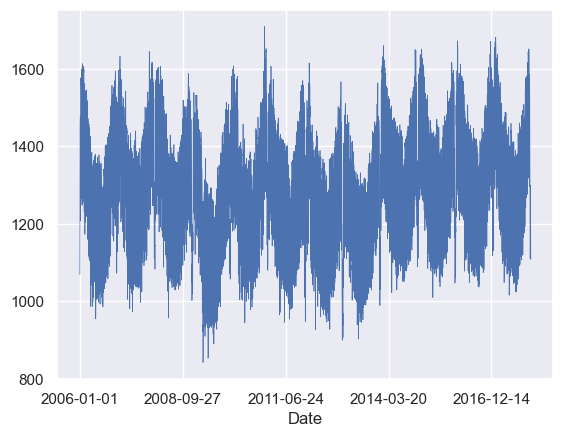

In [18]:
# sns.set(rc = {'figure.figsize:(10,4)'})
data['Consumption'].plot(linewidth = 0.5)

### seasonality 

In [ ]:
data['Month'] = data.index.month

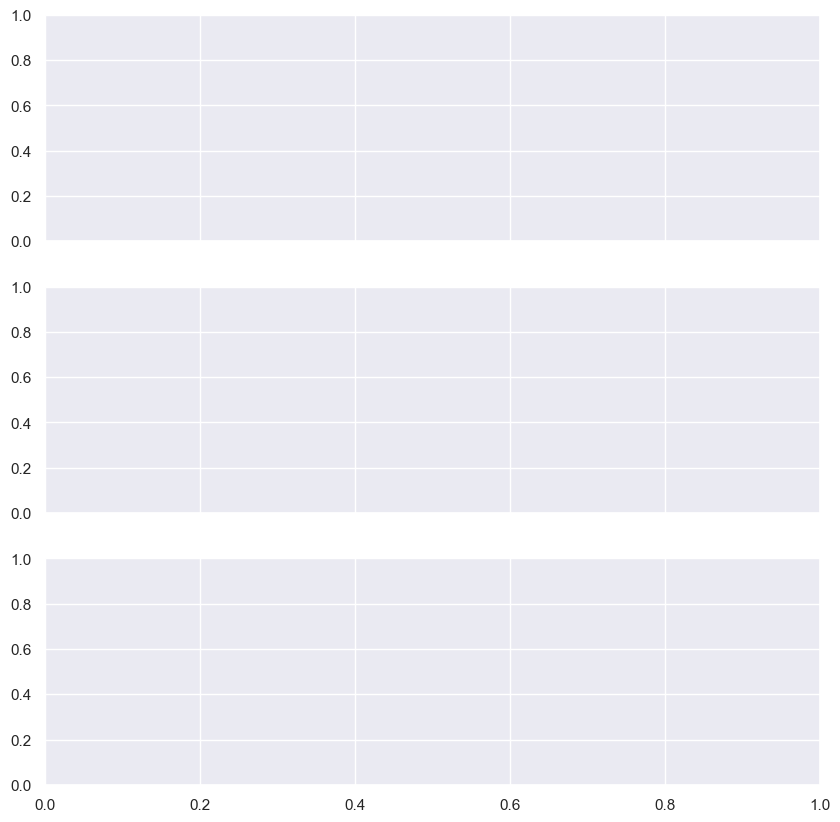

In [30]:
fig , axes = plt.subplots(3 , 1 , figsize = (10 , 10) , sharex = True)
for name , ax in zip(['Consumption' , 'Solar' , 'Wind'] , axes):
    sns.boxplot(data = data , x = 'Month'  , y = name , ax = ax)

### frequences 

In [26]:
pd.date_range(start = '1/1/2015' , end = '1/1/2016' , freq = 'H')

/var/folders/kp/kvtvt_zj31d2kf5lsslb61nh0000gn/T/ipykernel_94035/1581416363.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start = '1/1/2015' , end = '1/1/2016' , freq = 'H')


DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 15:00:00', '2015-12-31 16:00:00',
               '2015-12-31 17:00:00', '2015-12-31 18:00:00',
               '2015-12-31 19:00:00', '2015-12-31 20:00:00',
               '2015-12-31 21:00:00', '2015-12-31 22:00:00',
               '2015-12-31 23:00:00', '2016-01-01 00:00:00'],
              dtype='datetime64[ns]', length=8761, freq='h')

### resampling 

In [27]:
time_samples = pd.to_datetime(['2015-02-02' , '2014-02-05' , '2014-02-08'])

In [ ]:
consum_sample = data.loc[time_samples ,'Consumption'].copy() 

In [ ]:
# method = ffill : thêm các giá trị còn thiếu bằng các giá trị trước đó 
consum_freq = consum_sample.asfreq('D' , method = 'ffill')
consum_freq.loc

In [ ]:
# method = bfill : thêm các giá trị còn thiếu bằng các giá trị sau đó 
consum_sample.asfreq('D' , method = 'bfill')

## resampling 

- gom nhóm sample để tính trung bình 

- downsampling 
- upsampling 

In [ ]:
data_col = ['Consumption' , 'Wind' , 'Solar' , 'Wind+Solar']
opsd_weekly_mean = data[data_col].resample('M').mean()
opsd_weekly_mean

### rolling window

### trends